In [21]:
import requests
import io
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point
from pathlib import Path
from tqdm import tqdm

# ── Load clean data from Phase 1 and Phase 2 ─────────────────────────────────
lsr = pd.read_parquet("../data/lsr_clean_ws2024.parquet", engine="fastparquet")
ffw = gpd.read_parquet("../data/ffw_polygons_ws2024.parquet")

print(f"LSRs loaded:    {len(lsr):,}")
print(f"FFW polygons:   {len(ffw):,}")

LSRs loaded:    4,730
FFW polygons:   3,700


In [22]:
print("=" * 55)
print("PREPARING DATA FOR SPATIOTEMPORAL JOIN")
print("=" * 55)

# ── Step 1: Convert LSR timestamps to datetime with UTC ───────────────────────
# VALID column is currently an integer like 202404011250
lsr["valid_utc"] = pd.to_datetime(lsr["VALID"].astype(str), format="%Y%m%d%H%M", utc=True)
print(f"LSR time range: {lsr['valid_utc'].min()} → {lsr['valid_utc'].max()}")

# ── Step 2: Convert LSRs to GeoDataFrame with point geometry ─────────────────
# Right now LSRs are just a plain DataFrame with LAT/LON columns
# For spatial operations we need them as actual geometry objects
lsr_geo = gpd.GeoDataFrame(
    lsr,
    geometry=gpd.points_from_xy(lsr["LON"], lsr["LAT"]),
    crs="EPSG:4326"
)
print(f"\nLSR GeoDataFrame created")
print(f"Geometry type: {lsr_geo.geometry.geom_type.unique()}")
print(f"CRS: {lsr_geo.crs}")

# ── Step 3: Confirm FFW CRS matches ──────────────────────────────────────────
print(f"\nFFW CRS: {ffw.crs}")
print(f"CRS match: {lsr_geo.crs == ffw.crs}")

# ── Step 4: Build spatial index on LSRs for fast lookup ──────────────────────
# GeoPandas builds an R-tree spatial index automatically
# This makes point-in-polygon queries much faster
lsr_sindex = lsr_geo.sindex
print(f"\nSpatial index built on LSRs")
print(f"LSR spatial index size: {len(lsr_sindex)}")

PREPARING DATA FOR SPATIOTEMPORAL JOIN
LSR time range: 2024-04-01 12:50:00+00:00 → 2024-09-30 23:33:00+00:00

LSR GeoDataFrame created
Geometry type: ['Point']
CRS: EPSG:4326

FFW CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitu

In [23]:
from tqdm import tqdm

print("=" * 55)
print("SPATIOTEMPORAL JOIN")
print("=" * 55)
print(f"Joining {len(ffw):,} warnings against {len(lsr_geo):,} LSRs...")

results = []

for idx, warning in tqdm(ffw.iterrows(), total=len(ffw), desc="Processing warnings"):
    
    # ── Step 1: Spatial candidates from index (on full LSR set) ──────────────
    # Get indices of LSRs whose bounding box intersects the polygon
    candidate_positions = list(lsr_sindex.intersection(warning["geometry"].bounds))
    
    if len(candidate_positions) == 0:
        results.append({
            "WARNING_ID":        warning["WARNING_ID"],
            "verified":          False,
            "n_lsr_inside":      0,
            "first_lsr_minutes": np.nan,
        })
        continue
    
    # Get the actual candidate LSR rows from the full GeoDataFrame
    candidates = lsr_geo.iloc[candidate_positions]
    
    # ── Step 2: Temporal filter on candidates only ────────────────────────────
    grace_period = pd.Timedelta(minutes=60)
    temporal_mask = (
        (candidates["valid_utc"] >= warning["ISSUED"]) &
        (candidates["valid_utc"] <= warning["EXPIRED"] + grace_period)
    )
    candidates_temporal = candidates[temporal_mask]
    
    if len(candidates_temporal) == 0:
        results.append({
            "WARNING_ID":        warning["WARNING_ID"],
            "verified":          False,
            "n_lsr_inside":      0,
            "first_lsr_minutes": np.nan,
        })
        continue
    
    # ── Step 3: Exact point-in-polygon test ───────────────────────────────────
    # Buffer each LSR point by 5km before testing
    # Requires projected CRS — reproject temporarily
    warning_geom = warning["geometry"]
    lsr_buffered_temp = candidates_temporal.copy()
    lsr_buffered_temp = lsr_buffered_temp.to_crs("EPSG:5070")
    lsr_buffered_temp["geometry"] = lsr_buffered_temp.geometry.buffer(5000)
    lsr_buffered_temp = lsr_buffered_temp.to_crs("EPSG:4326")
    warning_geom_series = gpd.GeoSeries([warning_geom], crs="EPSG:4326")

    inside = lsr_buffered_temp[
        lsr_buffered_temp.geometry.intersects(warning_geom_series.iloc[0])
    ]
    
    verified = len(inside) > 0
    n_lsr_inside = len(inside)
    
    first_lsr_minutes = (
        (inside["valid_utc"].min() - warning["ISSUED"]).total_seconds() / 60
        if verified else np.nan
    )
    
    results.append({
        "WARNING_ID":        warning["WARNING_ID"],
        "verified":          verified,
        "n_lsr_inside":      n_lsr_inside,
        "first_lsr_minutes": first_lsr_minutes,
    })

results_df = pd.DataFrame(results)

print(f"\nJoin complete")
print(f"Total warnings:     {len(results_df):,}")
print(f"Verified:           {results_df['verified'].sum():,} ({results_df['verified'].mean()*100:.1f}%)")
print(f"Not verified (FAR): {(~results_df['verified']).sum():,} ({(~results_df['verified']).mean()*100:.1f}%)")
print(f"\nAmong verified warnings:")
print(f"  Median LSRs inside polygon: {results_df[results_df['verified']]['n_lsr_inside'].median():.0f}")
print(f"  Median lead time to first LSR: {results_df['first_lsr_minutes'].median():.0f} minutes")

SPATIOTEMPORAL JOIN
Joining 3,700 warnings against 4,730 LSRs...


Processing warnings: 100%|██████████| 3700/3700 [00:02<00:00, 1739.92it/s]


Join complete
Total warnings:     3,700
Verified:           1,672 (45.2%)
Not verified (FAR): 2,028 (54.8%)

Among verified warnings:
  Median LSRs inside polygon: 2
  Median lead time to first LSR: 43 minutes


In [24]:
print("=" * 55)
print("DIAGNOSING VERIFICATION RATE")
print("=" * 55)

# Merge results back onto the FFW GeoDataFrame
ffw_verified = ffw.merge(results_df, on="WARNING_ID")

# ── Verification rate by WFO ──────────────────────────────────────────────────
wfo_stats = ffw_verified.groupby("WFO").agg(
    total    = ("verified", "count"),
    verified = ("verified", "sum"),
).assign(rate=lambda x: x["verified"] / x["total"] * 100).sort_values("rate", ascending=False)

print("\nTop 10 WFOs by verification rate (min 10 warnings):")
print(wfo_stats[wfo_stats["total"] >= 10].head(10).to_string())

print("\nBottom 10 WFOs by verification rate (min 10 warnings):")
print(wfo_stats[wfo_stats["total"] >= 10].tail(10).to_string())

# ── Verification rate by month ────────────────────────────────────────────────
ffw_verified["month"] = ffw_verified["ISSUED"].dt.month
monthly_stats = ffw_verified.groupby("month").agg(
    total    = ("verified", "count"),
    verified = ("verified", "sum"),
).assign(rate=lambda x: x["verified"] / x["total"] * 100)
monthly_stats.index = ["Apr", "May", "Jun", "Jul", "Aug", "Sep"]

print("\nVerification rate by month:")
print(monthly_stats.to_string())

# ── Distribution of n_lsr_inside ─────────────────────────────────────────────
print("\nDistribution of LSRs inside polygon (verified warnings only):")
print(ffw_verified[ffw_verified["verified"]]["n_lsr_inside"].describe().round(1).to_string())

DIAGNOSING VERIFICATION RATE

Top 10 WFOs by verification rate (min 10 warnings):
     total  verified       rate
WFO                            
EAX     28        24  85.714286
FSD     34        29  85.294118
BUF     22        17  77.272727
BTV     22        17  77.272727
AKQ    128        95  74.218750
TAE    100        73  73.000000
CAE     44        32  72.727273
MHX     35        25  71.428571
ALY     10         7  70.000000
CTP     33        23  69.696970

Bottom 10 WFOs by verification rate (min 10 warnings):
     total  verified       rate
WFO                            
JAX     19         4  21.052632
AMA     27         5  18.518519
TWC    102        18  17.647059
FGZ     92        16  17.391304
TSA     35         6  17.142857
PUB     26         4  15.384615
EPZ     66         9  13.636364
SGX     21         2   9.523810
GJT     56         4   7.142857
REV     10         0   0.000000

Verification rate by month:
     total  verified       rate
Apr    219       138  63.013699
M

In [25]:
print("=" * 55)
print("ASSEMBLING FINAL LABELED DATASET")
print("=" * 55)

# Merge verification results onto FFW GeoDataFrame
ffw_labeled = ffw.merge(results_df, on="WARNING_ID")

# ── Add centroid coordinates for GWR later ────────────────────────────────────
# Project to equal-area CRS for accurate centroid computation
ffw_projected = ffw_labeled.to_crs("EPSG:5070")  # Albers Equal Area CONUS
ffw_labeled["centroid_lon"] = ffw_projected.geometry.centroid.to_crs("EPSG:4326").x
ffw_labeled["centroid_lat"] = ffw_projected.geometry.centroid.to_crs("EPSG:4326").y

# ── Add month and hour for baseline model later ───────────────────────────────
ffw_labeled["issued_month"] = ffw_labeled["ISSUED"].dt.month
ffw_labeled["issued_hour"]  = ffw_labeled["ISSUED"].dt.hour

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Total warnings:         {len(ffw_labeled):,}")
print(f"Verified:               {ffw_labeled['verified'].sum():,} ({ffw_labeled['verified'].mean()*100:.1f}%)")
print(f"Not verified:           {(~ffw_labeled['verified']).sum():,}")
print(f"\nColumns added: verified, n_lsr_inside, first_lsr_minutes,")
print(f"               centroid_lon, centroid_lat, issued_month, issued_hour")
print(f"\nFinal shape: {ffw_labeled.shape}")

# ── Save ──────────────────────────────────────────────────────────────────────
ffw_labeled.to_parquet("../data/ffw_labeled_ws2024.parquet", index=False)
print(f"\nSaved → data/ffw_labeled_ws2024.parquet")
print(f"This is your training dataset foundation.")

ASSEMBLING FINAL LABELED DATASET
Total warnings:         3,700
Verified:               1,672 (45.2%)
Not verified:           2,028

Columns added: verified, n_lsr_inside, first_lsr_minutes,
               centroid_lon, centroid_lat, issued_month, issued_hour

Final shape: (3700, 37)

Saved → data/ffw_labeled_ws2024.parquet
This is your training dataset foundation.


WFOs with >= 5 warnings: 90


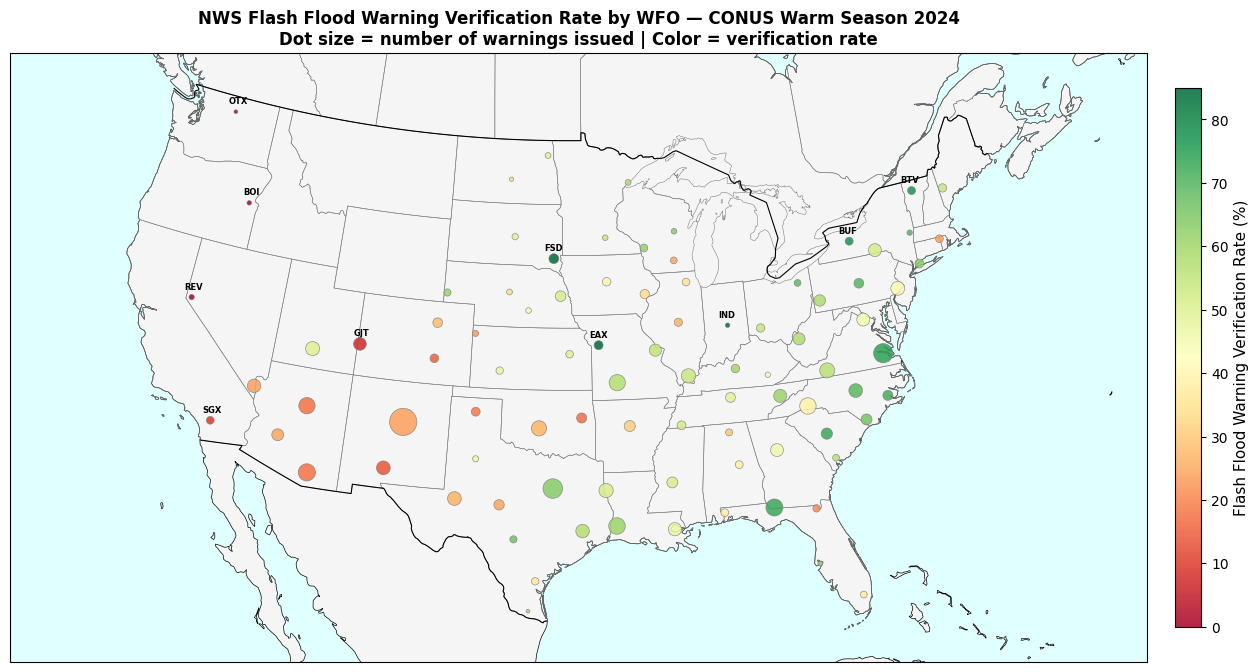

Saved → figures/wfo_verification_rate.png


In [26]:
# Compute verification rate per WFO from our labeled data
wfo_stats = ffw_labeled.groupby("WFO").agg(
    total    = ("verified", "count"),
    verified = ("verified", "sum"),
    mean_lat = ("centroid_lat", "mean"),
    mean_lon = ("centroid_lon", "mean"),
).reset_index()

wfo_stats["verif_rate"] = wfo_stats["verified"] / wfo_stats["total"] * 100

# Only plot WFOs with at least 5 warnings for statistical reliability
wfo_plot = wfo_stats[wfo_stats["total"] >= 5].copy()
print(f"WFOs with >= 5 warnings: {len(wfo_plot)}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.LambertConformal()}
)

ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,      facecolor="whitesmoke")
ax.add_feature(cfeature.OCEAN,     facecolor="lightcyan")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.STATES,    linewidth=0.4, edgecolor="gray")
ax.add_feature(cfeature.BORDERS,   linewidth=0.8, edgecolor="black")

# ── Scatter plot sized by warning count, colored by verification rate ─────────
sc = ax.scatter(
    wfo_plot["mean_lon"],
    wfo_plot["mean_lat"],
    c=wfo_plot["verif_rate"],
    s=wfo_plot["total"] * 1.5,   # size = warning count
    cmap="RdYlGn",
    vmin=0, vmax=85,
    transform=ccrs.PlateCarree(),
    alpha=0.85,
    edgecolors="gray",
    linewidths=0.5,
    zorder=5
)

# ── Label WFOs with extreme rates ─────────────────────────────────────────────
for _, row in wfo_plot.iterrows():
    if row["verif_rate"] >= 75 or row["verif_rate"] <= 10:
        ax.text(
            row["mean_lon"], row["mean_lat"] + 0.4,
            row["WFO"],
            transform=ccrs.PlateCarree(),
            fontsize=6, ha="center", color="black", fontweight="bold"
        )

cbar = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02, shrink=0.7)
cbar.set_label("Flash Flood Warning Verification Rate (%)", fontsize=11)

ax.set_title(
    "NWS Flash Flood Warning Verification Rate by WFO — CONUS Warm Season 2024\n"
    "Dot size = number of warnings issued | Color = verification rate",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.savefig("../figures/wfo_verification_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/wfo_verification_rate.png")

In [27]:
from shapely.ops import unary_union
from tqdm import tqdm

print("=" * 55)
print("COMPUTING FALSE ALARM FRACTION")
print("=" * 55)
print("5km buffer around each LSR point...")
print("This will take 2-4 minutes...")

# Project to meters for accurate buffer computation
lsr_proj  = lsr_geo.to_crs("EPSG:5070")   # Albers Equal Area, units = meters
ffw_proj  = ffw_labeled.to_crs("EPSG:5070")

# Pre-compute 5km buffer around every LSR point
lsr_buffered = lsr_proj.copy()
lsr_buffered["geometry"] = lsr_proj.geometry.buffer(5000)  # 5000 meters = 5km

# Rebuild spatial index on buffered LSRs
lsr_buf_sindex = lsr_buffered.sindex

fa_fractions = []

for idx, warning in tqdm(ffw_proj.iterrows(), total=len(ffw_proj), desc="False alarm fraction"):
    
    poly = warning["geometry"]
    poly_area = poly.area
    
    if poly_area == 0:
        fa_fractions.append(np.nan)
        continue
    
    # Get candidate buffered LSRs near this polygon
    candidate_pos = list(lsr_buf_sindex.intersection(poly.bounds))
    
    if len(candidate_pos) == 0:
        # No LSR buffers anywhere near polygon — 100% false alarm area
        fa_fractions.append(1.0)
        continue
    
    candidates = lsr_buffered.iloc[candidate_pos]
    
    # Temporal filter
    grace_period = pd.Timedelta(minutes=60)
    temporal_mask = (
        (candidates["valid_utc"] >= warning["ISSUED"]) &
        (candidates["valid_utc"] <= warning["EXPIRED"] + grace_period)
    )
    candidates_temporal = candidates[temporal_mask]
    
    if len(candidates_temporal) == 0:
        fa_fractions.append(1.0)
        continue
    
    # Union of all LSR buffers that intersect this polygon temporally
    lsr_union = unary_union(candidates_temporal.geometry.values)
    
    # Intersection of LSR union with the warning polygon
    covered_area = poly.intersection(lsr_union).area
    
    # False alarm fraction = uncovered area / total polygon area
    fa_fraction = 1.0 - (covered_area / poly_area)
    fa_fraction = max(0.0, min(1.0, fa_fraction))  # clip to [0, 1]
    
    fa_fractions.append(fa_fraction)

ffw_labeled["false_alarm_fraction"] = fa_fractions

print(f"\nFalse alarm fraction computed for {len(fa_fractions):,} warnings")
print(f"\nDistribution:")
print(ffw_labeled["false_alarm_fraction"].describe().round(3).to_string())
print(f"\nVerified warnings — mean false alarm fraction: {ffw_labeled[ffw_labeled['verified']]['false_alarm_fraction'].mean():.3f}")
print(f"Unverified warnings — mean false alarm fraction: {ffw_labeled[~ffw_labeled['verified']]['false_alarm_fraction'].mean():.3f}")

# Force unverified warnings to exactly 1.0 — consistent with binary label
ffw_labeled.loc[~ffw_labeled["verified"], "false_alarm_fraction"] = 1.0

print("Unverified warnings forced to false_alarm_fraction = 1.0")
print(f"Verified mean:   {ffw_labeled[ffw_labeled['verified']]['false_alarm_fraction'].mean():.3f}")
print(f"Unverified mean: {ffw_labeled[~ffw_labeled['verified']]['false_alarm_fraction'].mean():.3f}")

COMPUTING FALSE ALARM FRACTION
5km buffer around each LSR point...
This will take 2-4 minutes...


False alarm fraction: 100%|██████████| 3700/3700 [00:01<00:00, 3126.89it/s]


False alarm fraction computed for 3,700 warnings

Distribution:
count    3700.000
mean        0.924
std         0.145
min         0.000
25%         0.910
50%         1.000
75%         1.000
max         1.000

Verified warnings — mean false alarm fraction: 0.835
Unverified warnings — mean false alarm fraction: 0.998
Unverified warnings forced to false_alarm_fraction = 1.0
Verified mean:   0.835
Unverified mean: 1.000


In [28]:
ffw_labeled.to_parquet(
    "../data/ffw_labeled_ws2024.parquet",
    index=False
)
print(f"Saved → data/ffw_labeled_ws2024.parquet")
print(f"Shape: {ffw_labeled.shape}")
print(f"Columns: {ffw_labeled.columns.tolist()}")

Saved → data/ffw_labeled_ws2024.parquet
Shape: (3700, 38)
Columns: ['WFO', 'ISSUED', 'EXPIRED', 'INIT_ISS', 'INIT_EXP', 'PHENOM', 'GTYPE', 'SIG', 'ETN', 'STATUS', 'NWS_UGC', 'AREA_KM2', 'UPDATED', 'HV_NWSLI', 'HV_SEV', 'HV_CAUSE', 'HV_REC', 'EMERGENC', 'POLY_BEG', 'POLY_END', 'WINDTAG', 'HAILTAG', 'TORNTAG', 'DAMAGTAG', 'PROD_ID', 'FCSTER', 'VTEC_YR', 'geometry', 'duration_min', 'WARNING_ID', 'verified', 'n_lsr_inside', 'first_lsr_minutes', 'centroid_lon', 'centroid_lat', 'issued_month', 'issued_hour', 'false_alarm_fraction']


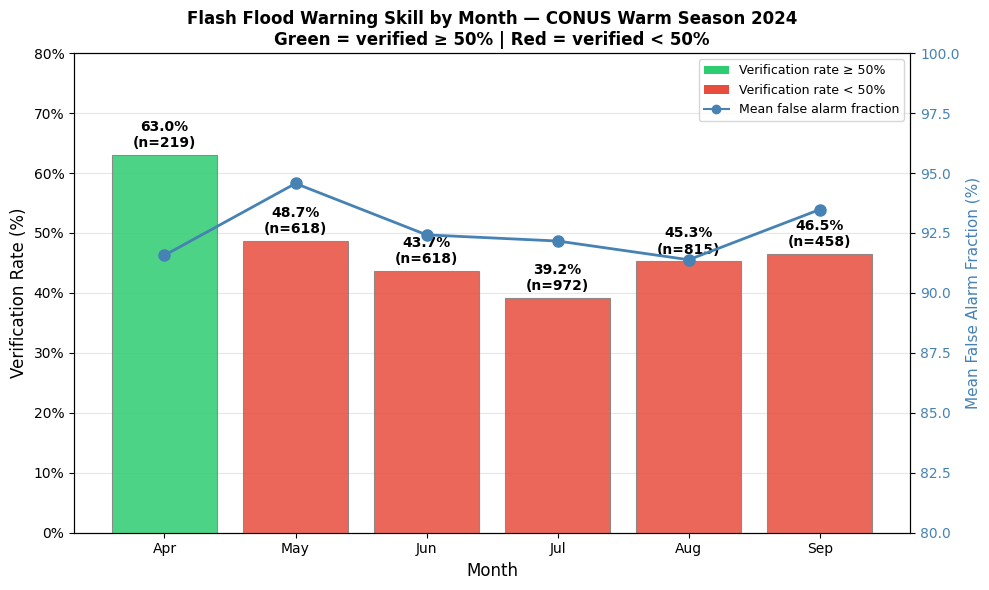

Saved → figures/monthly_verification.png


In [29]:
import matplotlib.ticker as mticker

monthly_stats = ffw_labeled.groupby("issued_month").agg(
    total    = ("verified", "count"),
    verified = ("verified", "sum"),
    fa_frac  = ("false_alarm_fraction", "mean")
).reset_index()

monthly_stats["verif_rate"] = monthly_stats["verified"] / monthly_stats["total"] * 100
monthly_stats["month_name"] = ["Apr", "May", "Jun", "Jul", "Aug", "Sep"]

fig, ax1 = plt.subplots(figsize=(10, 6))

# ── Bar chart: verification rate ──────────────────────────────────────────────
colors = ["#2ecc71" if r >= 50 else "#e74c3c" for r in monthly_stats["verif_rate"]]
bars = ax1.bar(
    monthly_stats["month_name"],
    monthly_stats["verif_rate"],
    color=colors,
    alpha=0.85,
    edgecolor="gray",
    linewidth=0.8,
    zorder=3
)

# ── Annotate bars with count and rate ────────────────────────────────────────
for bar, (_, row) in zip(bars, monthly_stats.iterrows()):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{row['verif_rate']:.1f}%\n(n={row['total']:,})",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

# ── Secondary axis: false alarm fraction ──────────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(
    monthly_stats["month_name"],
    monthly_stats["fa_frac"] * 100,
    color="steelblue",
    marker="o",
    linewidth=2,
    markersize=8,
    label="Mean false alarm fraction (%)",
    zorder=5
)
ax2.set_ylabel("Mean False Alarm Fraction (%)", fontsize=11, color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2.set_ylim(80, 100)

ax1.set_xlabel("Month", fontsize=12)
ax1.set_ylabel("Verification Rate (%)", fontsize=12)
ax1.set_ylim(0, 80)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.grid(axis="y", alpha=0.3, zorder=0)
ax1.set_title(
    "Flash Flood Warning Skill by Month — CONUS Warm Season 2024\n"
    "Green = verified ≥ 50% | Red = verified < 50%",
    fontsize=12, fontweight="bold"
)

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="Verification rate ≥ 50%"),
    Patch(facecolor="#e74c3c", label="Verification rate < 50%"),
    plt.Line2D([0], [0], color="steelblue", marker="o", label="Mean false alarm fraction"),
]
ax1.legend(handles=legend_elements, loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("../figures/monthly_verification.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/monthly_verification.png")

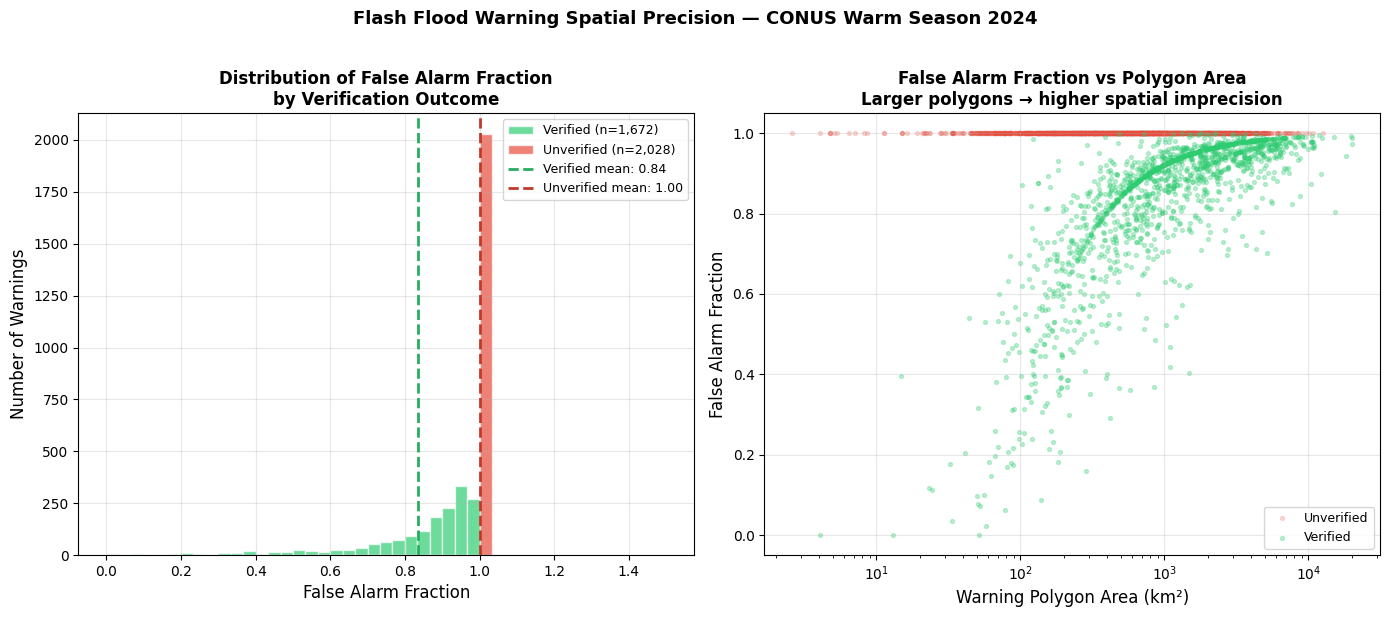

Saved → figures/false_alarm_fraction.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: histogram of false alarm fraction for all warnings ──────────────────
ax = axes[0]

verified_fa   = ffw_labeled[ffw_labeled["verified"]]["false_alarm_fraction"]
unverified_fa = ffw_labeled[~ffw_labeled["verified"]]["false_alarm_fraction"]

ax.hist(verified_fa,   bins=30, alpha=0.7, color="#2ecc71",
        label=f"Verified (n={len(verified_fa):,})",   edgecolor="white")
ax.hist(unverified_fa, bins=30, alpha=0.7, color="#e74c3c",
        label=f"Unverified (n={len(unverified_fa):,})", edgecolor="white")

ax.axvline(verified_fa.mean(),   color="#27ae60", linewidth=2,
           linestyle="--", label=f"Verified mean: {verified_fa.mean():.2f}")
ax.axvline(unverified_fa.mean(), color="#c0392b", linewidth=2,
           linestyle="--", label=f"Unverified mean: {unverified_fa.mean():.2f}")

ax.set_xlabel("False Alarm Fraction", fontsize=12)
ax.set_ylabel("Number of Warnings", fontsize=12)
ax.set_title("Distribution of False Alarm Fraction\nby Verification Outcome", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Right: false alarm fraction vs polygon area (scatter) ─────────────────────
ax = axes[1]

verified_df   = ffw_labeled[ffw_labeled["verified"]]
unverified_df = ffw_labeled[~ffw_labeled["verified"]]

ax.scatter(
    unverified_df["AREA_KM2"],
    unverified_df["false_alarm_fraction"],
    alpha=0.2, s=8, color="#e74c3c", label="Unverified"
)
ax.scatter(
    verified_df["AREA_KM2"],
    verified_df["false_alarm_fraction"],
    alpha=0.3, s=8, color="#2ecc71", label="Verified"
)

ax.set_xlabel("Warning Polygon Area (km²)", fontsize=12)
ax.set_ylabel("False Alarm Fraction", fontsize=12)
ax.set_title("False Alarm Fraction vs Polygon Area\nLarger polygons → higher spatial imprecision", 
             fontsize=12, fontweight="bold")
ax.set_xscale("log")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle(
    "Flash Flood Warning Spatial Precision — CONUS Warm Season 2024",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("../figures/false_alarm_fraction.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/false_alarm_fraction.png")